In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('D:/projects/AI_ML_LEARNING/IPL_Ball_by_Ball_2008_2022.csv')
deliveries_faced = df[df['extra_type'] != 'wides'].groupby('batter').size()
most_deliveries_player = deliveries_faced.idxmax()
most_deliveries_count = deliveries_faced.max()

sixes_df = df[df['batsman_run'] == 6]
sixes = sixes_df.groupby('batter').size()
most_sixes_player = sixes.idxmax()
most_sixes_count = sixes.max()
catches_df = df[df['kind'] == 'caught']
catches = catches_df.groupby('fielders_involved').size()
most_catches_player = catches.idxmax()
most_catches_count = catches.max()
lbw_df = df[df['kind'] == 'lbw']
lbw = lbw_df.groupby('bowler').size()
most_lbw_player = lbw.idxmax()
most_lbw_count = lbw.max()
valid_dismissals = ['bowled', 'caught', 'lbw', 'stumped', 'caught and bowled', 'hit wicket']
wickets_df = df[df['kind'].isin(valid_dismissals)]
wickets = wickets_df.groupby('bowler').size()
most_wickets_player = wickets.idxmax()
most_wickets_count = wickets.max()
print("--- Historical Player Statistics ---")
print(f"Faced highest number of deliveries: {most_deliveries_player} ({most_deliveries_count} balls)")
print(f"Hit highest number of sixes: {most_sixes_player} ({most_sixes_count} sixes)")
print(f"Taken highest number of catches: {most_catches_player} ({most_catches_count} catches)")
print(f"Taken highest number of LBW wickets: {most_lbw_player} ({most_lbw_count} wickets)")
print(f"Taken highest number of wickets: {most_wickets_player} ({most_wickets_count} wickets)")

--- Historical Player Statistics ---
Faced highest number of deliveries: V Kohli (5133 balls)
Hit highest number of sixes: CH Gayle (359 sixes)
Taken highest number of catches: MS Dhoni (135 catches)
Taken highest number of LBW wickets: Rashid Khan (28 wickets)
Taken highest number of wickets: DJ Bravo (183 wickets)


In [8]:

batsman_stats = df.groupby('batter').agg(
    total_runs=('batsman_run', 'sum'),
    balls_faced=('extra_type', lambda x: (x != 'wides').sum())
).reset_index()

qualified_batsmen = batsman_stats[batsman_stats['balls_faced'] >= 50].copy()

qualified_batsmen['strike_rate'] = np.round(
    (qualified_batsmen['total_runs'] / qualified_batsmen['balls_faced']) * 100, 2
)

top5_strike_rate = qualified_batsmen.sort_values(
    by='strike_rate',
    ascending=False
).head(5)

print("Top 5 Batsmen by Strike Rate (Min 50 Balls Faced)")
print(
    top5_strike_rate[
        ['batter', 'total_runs', 'balls_faced', 'strike_rate']
    ].to_string(index=False)
)

Top 5 Batsmen by Strike Rate (Min 50 Balls Faced)
     batter  total_runs  balls_faced  strike_rate
   TH David         187           89       210.11
 AD Russell        2039         1147       177.77
  LJ Wright         106           60       176.67
  KK Cooper         116           68       170.59
BCJ Cutting         238          141       168.79


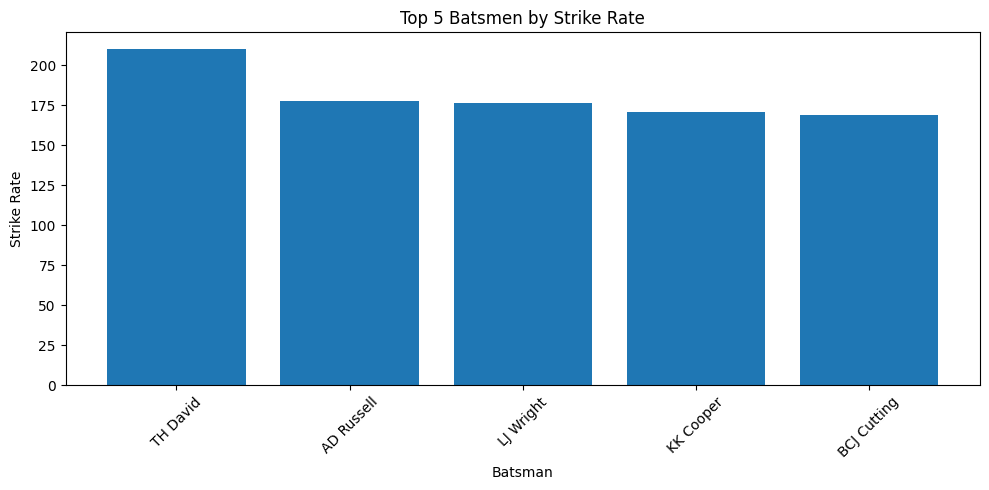

In [9]:
plt.figure(figsize=(10, 5))

plt.bar(
    top5_strike_rate['batter'],
    top5_strike_rate['strike_rate']
)

plt.title('Top 5 Batsmen by Strike Rate')
plt.xlabel('Batsman')
plt.ylabel('Strike Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()